# Feynman–Kac Formula: From PDEs to Stochastic Expectations

## What is it?
The **Feynman–Kac formula** creates a bridge between **parabolic PDEs** and **stochastic processes**. It states that the solution to a certain PDE can be written as an **expectation over paths of a diffusion process**.

## The General PDE
Consider the backward parabolic PDE for $u(x,t)$ with $t \leq T$:

$$\frac{\partial u}{\partial t} + \mu(x,t)\frac{\partial u}{\partial x} + \frac{1}{2}\sigma^2(x,t)\frac{\partial^2 u}{\partial x^2} - V(x,t)u + f(x,t) = 0$$

with terminal condition:
$$u(x,T) = g(x)$$

## The Feynman–Kac Representation
The solution is:

$$u(x,t) = \mathbb{E}\left[ \int_t^T e^{-\int_t^s V(X_r,r)\,dr} f(X_s,s)\,ds \;+\; e^{-\int_t^T V(X_r,r)\,dr} g(X_T) \;\Big|\; X_t = x \right]$$

where the stochastic process $X_s$ follows:
$$dX_s = \mu(X_s,s)\,ds + \sigma(X_s,s)\,dW_s$$

## Key Intuition
- **Diffusion term** $\frac{1}{2}\sigma^2 \partial_{xx}u$ $\leftrightarrow$ random motion of $X_t$.
- **Drift term** $\mu \partial_x u$ $\leftrightarrow$ deterministic drift of $X_t$.
- **Potential/killing rate** $V$ $\leftrightarrow$ exponential discounting along each path.
- **Source term** $f$ $\leftrightarrow$ running reward accumulated along the path.
- **Terminal condition** $g$ $\leftrightarrow$ final payoff at time $T$.

## Special Cases
1. **$V=0, f=0$**: Pure expectation of terminal payoff. (Heat equation)
2. **$V=r, f=0$**: Discounted expectation. (Black–Scholes)
3. **$V>0$**: "Killing" — paths are weighted down by survival probability.
4. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# ============ GLOBAL PARAMETERS ============
T = 1.0          # Terminal time
N = 500          # Time steps for path simulations
dt = T / N       # Base time step
t_grid = np.linspace(0, T, N + 1)

n_mc_surf = 5000   # MC paths for surface plots
n_mc_line = 15000  # MC paths for line plots
n_mc_bs = 20000    # MC paths for Black-Scholes


## Case 1: Pure Diffusion (Heat Equation)

**PDE:** $\displaystyle \frac{\partial u}{\partial t} + \frac{1}{2}\sigma^2 \frac{\partial^2 u}{\partial x^2} = 0$

**Terminal condition:** $u(x,T) = g(x) = \sin(x)$

**SDE:** $dX_s = \sigma\,dW_s$, so $X_T \sim \mathcal{N}(X_t, \sigma^2(T-t))$

**Exact solution:** Since the heat kernel convolves $g$ with a Gaussian,
$$u(x,t) = \mathbb{E}[\sin(X_T)\,|\,X_t=x] = \sin(x)\,e^{-\frac{1}{2}\sigma^2(T-t)}$$

The left panel shows sample paths of the diffusion starting from different $x_0$.  
The right panel shows the terminal payoff $g(x)=\sin(x)$.


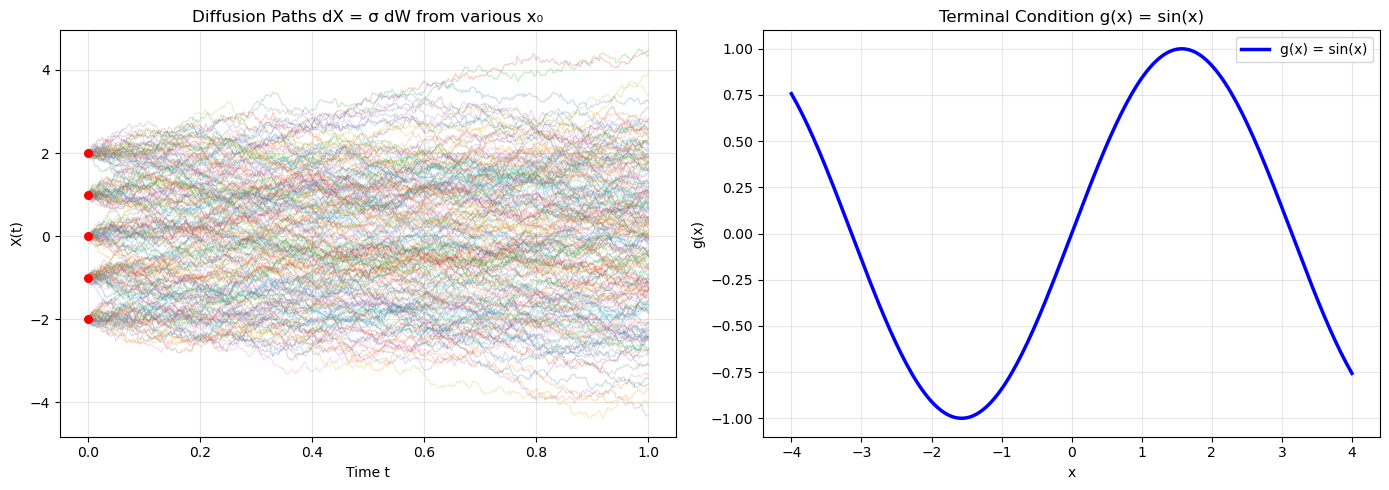

In [2]:
# ============ PLOT 1: Paths and Terminal Condition ============
sigma = 1.0
x0_values = np.array([-2, -1, 0, 1, 2])
n_paths_viz = 40

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: paths from different starting points
ax = axes[0]
for x0 in x0_values:
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths_viz, N))
    X = np.zeros((n_paths_viz, N + 1))
    X[:, 0] = x0
    X[:, 1:] = x0 + sigma * np.cumsum(dW, axis=1)
    for i in range(n_paths_viz):
        ax.plot(t_grid, X[i], alpha=0.25, linewidth=0.8)
    ax.scatter([0], [x0], color='red', zorder=5, s=30)

ax.set_title('Diffusion Paths dX = σ dW from various x₀', fontsize=12)
ax.set_xlabel('Time t')
ax.set_ylabel('X(t)')
ax.grid(True, alpha=0.3)

# Right: terminal payoff
ax = axes[1]
x_range = np.linspace(-4, 4, 200)
ax.plot(x_range, np.sin(x_range), 'b-', linewidth=2.5, label='g(x) = sin(x)')
ax.set_title('Terminal Condition g(x) = sin(x)', fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('g(x)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Case 2: Solution Surface $u(x,t)$

We now compute $u(x,t)$ on a grid via the Feynman–Kac expectation and compare it to the exact solution.

For each $(x_i, t_j)$ on the grid:
1. Set $X_{t_j} = x_i$.
2. Simulate many paths from $t_j$ to $T$.
3. Average $\sin(X_T)$ over all paths.

The result is a surface that shows how the terminal "wave" $\sin(x)$ decays backward in time due to diffusion.


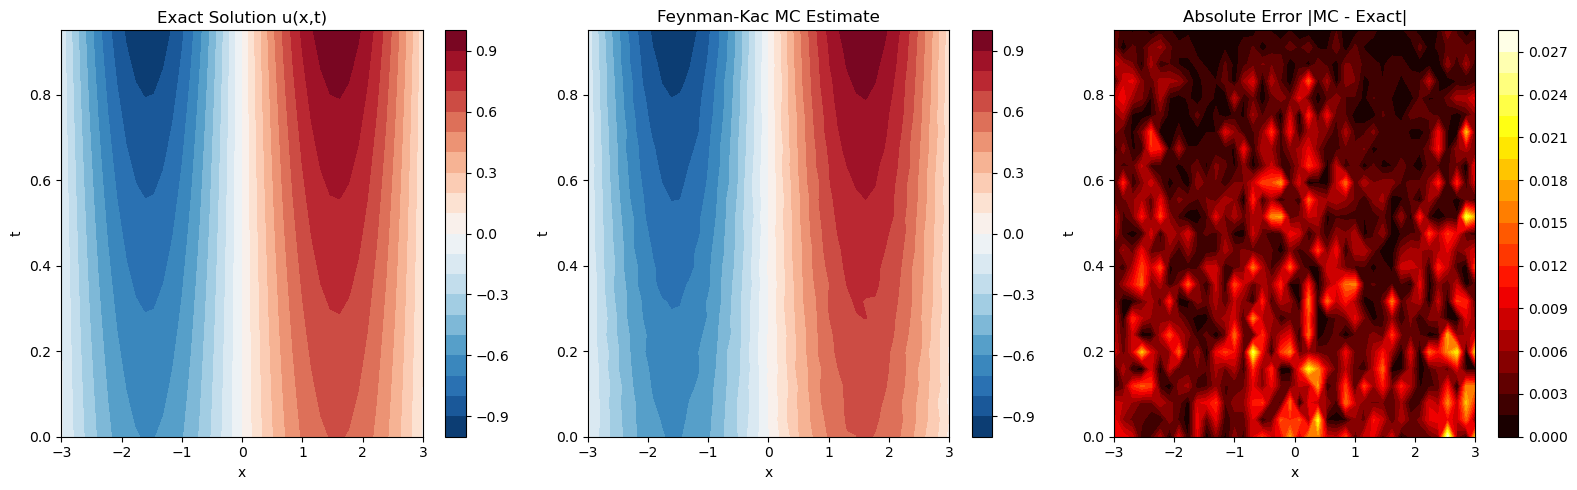

In [3]:
# ============ PLOT 2: Solution Surface u(x,t) ============
x_grid = np.linspace(-3, 3, 40)
t_grid_surf = np.linspace(0, 0.95 * T, 25)  # avoid tau=0 for MC

U_exact = np.zeros((len(t_grid_surf), len(x_grid)))
U_mc = np.zeros((len(t_grid_surf), len(x_grid)))

for i, t in enumerate(t_grid_surf):
    tau = T - t
    # Exact solution: sin(x) * exp(-0.5 * sigma^2 * tau)
    U_exact[i, :] = np.sin(x_grid) * np.exp(-0.5 * sigma**2 * tau)
    
    # MC via Feynman-Kac
    n_steps = max(1, int(tau / dt))
    dt_loc = tau / n_steps
    dW = np.random.normal(0, np.sqrt(dt_loc), size=(len(x_grid), n_mc_surf, n_steps))
    X_T = x_grid[:, None] + sigma * np.sum(dW, axis=2)
    payoff = np.sin(X_T)
    U_mc[i, :] = np.mean(payoff, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Exact
ax = axes[0]
cs = ax.contourf(x_grid, t_grid_surf, U_exact, levels=20, cmap='RdBu_r')
ax.set_title('Exact Solution u(x,t)', fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('t')
plt.colorbar(cs, ax=ax)

# MC
ax = axes[1]
cs = ax.contourf(x_grid, t_grid_surf, U_mc, levels=20, cmap='RdBu_r')
ax.set_title('Feynman-Kac MC Estimate', fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('t')
plt.colorbar(cs, ax=ax)

# Error
ax = axes[2]
cs = ax.contourf(x_grid, t_grid_surf, np.abs(U_mc - U_exact), levels=20, cmap='hot')
ax.set_title('Absolute Error |MC - Exact|', fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('t')
plt.colorbar(cs, ax=ax)

plt.tight_layout()
plt.show()


## Case 3: Adding Drift $\mu$ and Potential $V$

Now we enrich the PDE:

$$\frac{\partial u}{\partial t} + \mu\frac{\partial u}{\partial x} + \frac{1}{2}\sigma^2\frac{\partial^2 u}{\partial x^2} - V u = 0$$

**With drift only** ($\mu=0.5, V=0$):  
Exact: $u(x,t) = \sin(x + \mu(T-t))\,e^{-\frac{1}{2}\sigma^2(T-t)}$

**With drift and potential** ($\mu=0.5, V=1.0$):  
The potential adds exponential discounting:  
Exact: $u(x,t) = \sin(x + \mu(T-t))\,e^{-(\frac{1}{2}\sigma^2 + V)(T-t)}$

The plot compares all three cases at a fixed time $t=0.2$.


In [4]:
# ============ PLOT 3: Drift and Potential Comparison ============
t_fixed = 0.2
tau = T - t_fixed
n_steps = max(1, int(tau / dt))
dt_loc = tau / n_steps
x_fine = np.linspace(-3, 3, 100)

# Case 1: Pure diffusion
dW = np.random.normal(0, np.sqrt(dt_loc), size=(len(x_fine), n_mc_line, n_steps))
X_T = x_fine[:, None] + sigma * np.sum(dW, axis=2)
u_pure_mc = np.mean(np.sin(X_T), axis=1)
u_pure_exact = np.sin(x_fine) * np.exp(-0.5 * sigma**2 * tau)

# Case 2: With drift
mu = 0.5
dW = np.random.normal(0, np.sqrt(dt_loc), size=(len(x_fine), n_mc_line, n_steps))
X_T = x_fine[:, None] + mu * tau + sigma * np.sum(dW, axis=2)
u_drift_mc = np.mean(np.sin(X_T), axis=1)
u_drift_exact = np.sin(x_fine + mu * tau) * np.exp(-0.5 * sigma**2 * tau)

# Case 3: With drift and potential
V = 1.0
dW = np.random.normal(0, np.sqrt(dt_loc), size=(len(x_fine), n_mc_line, n_steps))
X_T = x_fine[:, None] + mu * tau + sigma * np.sum(dW, axis=2)
u_pot_mc = np.mean(np.sin(X_T) * np.exp(-V * tau), axis=1)
u_pot_exact = np.sin(x_fine + mu * tau) * np.exp(-(0.5 * sigma**2 + V) * tau)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_fine, u_pure_exact, 'b-', linewidth=2.5, label='Pure diffusion (exact)')
ax.plot(x_fine, u_pure_mc, 'b--', alpha=0.6, label='Pure diffusion (MC)')
ax.plot(x_fine, u_drift_exact, 'r-', linewidth=2.5, label='With drift μ=0.5 (exact)')
ax.plot(x_fine, u_drift_mc, 'r--', alpha=0.6, label='With drift (MC)')
ax.plot(x_fine, u_pot_exact, 'g-', linewidth=2.5, label='Drift + potential V=1.0 (exact)')
ax.plot(x_fine, u_pot_mc, 'g--', alpha=0.6, label='Drift + potential (MC)')

title = 'Solution Comparison at t = ' + str(t_fixed)
ax.set_title(title, fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('u(x, t)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<class 'ValueError'>: array is too big; `arr.size * arr.dtype.itemsize` is larger than the maximum possible size.

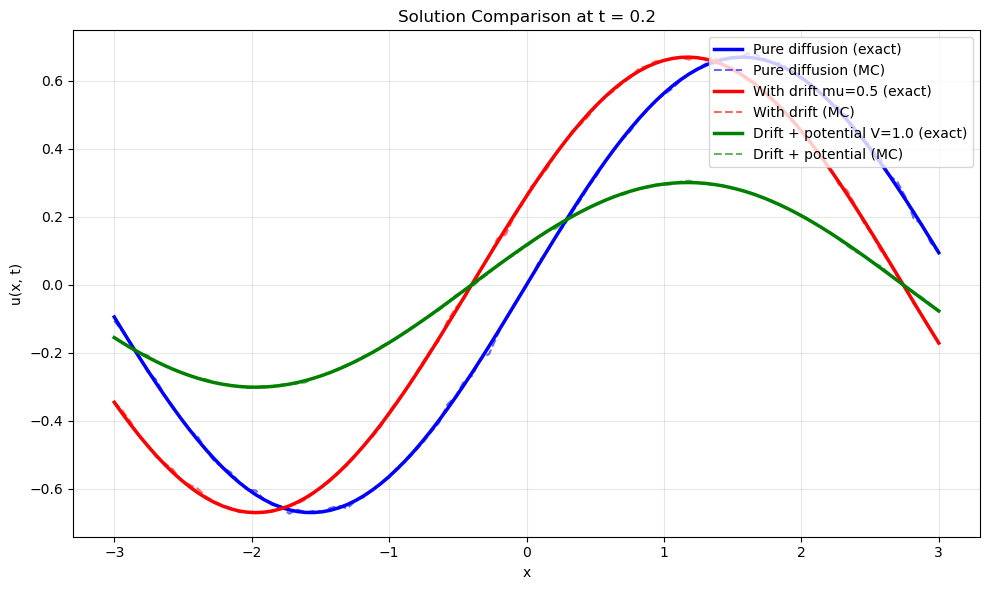

In [6]:
# ============ PLOT 3: Drift and Potential Comparison ============
t_fixed = 0.2
tau = T - t_fixed
n_steps = max(1, int(tau / dt))
dt_loc = tau / n_steps
x_fine = np.linspace(-3, 3, 100)
n_mc_line = 8000  # reduced slightly; still smooth

u_pure_mc = np.zeros_like(x_fine)
u_drift_mc = np.zeros_like(x_fine)
u_pot_mc = np.zeros_like(x_fine)

mu = 0.5
V = 1.0

for j, x in enumerate(x_fine):
    # Case 1: Pure diffusion
    dW = np.random.normal(0, np.sqrt(dt_loc), size=(n_mc_line, n_steps))
    X_T = x + sigma * np.sum(dW, axis=1)
    u_pure_mc[j] = np.mean(np.sin(X_T))

    # Case 2: With drift
    dW = np.random.normal(0, np.sqrt(dt_loc), size=(n_mc_line, n_steps))
    X_T = x + mu * tau + sigma * np.sum(dW, axis=1)
    u_drift_mc[j] = np.mean(np.sin(X_T))

    # Case 3: With drift and potential
    dW = np.random.normal(0, np.sqrt(dt_loc), size=(n_mc_line, n_steps))
    X_T = x + mu * tau + sigma * np.sum(dW, axis=1)
    u_pot_mc[j] = np.mean(np.sin(X_T) * np.exp(-V * tau))

# Exact solutions
u_pure_exact = np.sin(x_fine) * np.exp(-0.5 * sigma**2 * tau)
u_drift_exact = np.sin(x_fine + mu * tau) * np.exp(-0.5 * sigma**2 * tau)
u_pot_exact = np.sin(x_fine + mu * tau) * np.exp(-(0.5 * sigma**2 + V) * tau)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_fine, u_pure_exact, 'b-', linewidth=2.5, label='Pure diffusion (exact)')
ax.plot(x_fine, u_pure_mc, 'b--', alpha=0.6, label='Pure diffusion (MC)')
ax.plot(x_fine, u_drift_exact, 'r-', linewidth=2.5, label='With drift mu=0.5 (exact)')
ax.plot(x_fine, u_drift_mc, 'r--', alpha=0.6, label='With drift (MC)')
ax.plot(x_fine, u_pot_exact, 'g-', linewidth=2.5, label='Drift + potential V=1.0 (exact)')
ax.plot(x_fine, u_pot_mc, 'g--', alpha=0.6, label='Drift + potential (MC)')

title = 'Solution Comparison at t = ' + str(t_fixed)
ax.set_title(title, fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('u(x, t)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Case 4: Black–Scholes Option Pricing

The Black–Scholes PDE is a direct application of Feynman–Kac:

$$\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} - rV = 0$$

with terminal condition $V(S,T) = \max(S-K, 0)$ for a European call.

**Feynman–Kac representation:**
$$V(S,t) = e^{-r(T-t)}\,\mathbb{E}\left[ \max(S_T - K, 0) \,\big|\, S_t = S \right]$$

where $S_T$ follows geometric Brownian motion:
$$S_T = S_t \exp\left(\left(r - \tfrac{1}{2}\sigma^2\right)(T-t) + \sigma(W_T - W_t)\right)$$

We compare the analytical Black–Scholes formula against Monte Carlo evaluation of the expectation.


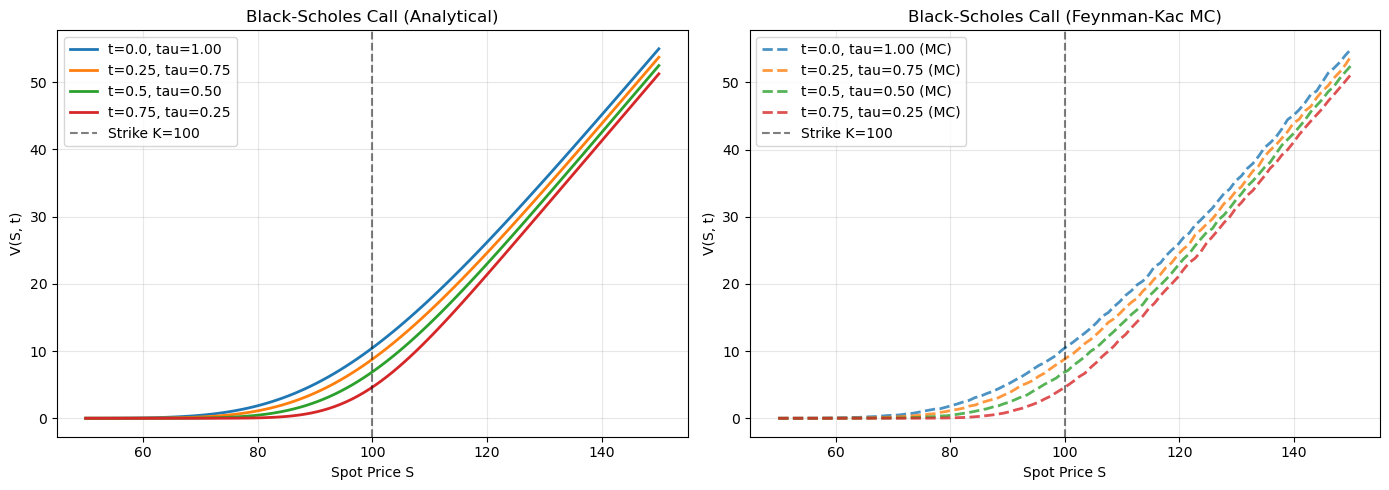

In [5]:
# ============ PLOT 4: Black-Scholes via Feynman-Kac ============
r = 0.05
sigma_bs = 0.2
K = 100
T_bs = 1.0
S_grid = np.linspace(50, 150, 100)
t_values = [0.0, 0.25, 0.5, 0.75]


def bs_call(S, K_val, T_val, r_val, sig):
    T_val = np.asarray(T_val)
    S = np.asarray(S)
    result = np.zeros_like(S, dtype=float)
    mask = T_val > 1e-10
    if np.any(mask):
        d1 = (np.log(S[mask] / K_val) + (r_val + 0.5 * sig**2) * T_val[mask])
        d1 = d1 / (sig * np.sqrt(T_val[mask]))
        d2 = d1 - sig * np.sqrt(T_val[mask])
        result[mask] = (S[mask] * stats.norm.cdf(d1)
                        - K_val * np.exp(-r_val * T_val[mask]) * stats.norm.cdf(d2))
    return result


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Analytical
ax = axes[0]
for t in t_values:
    tau = T_bs - t
    prices = bs_call(S_grid, K, tau, r, sigma_bs)
    label = 't=' + str(t) + ', tau=' + f'{tau:.2f}'
    ax.plot(S_grid, prices, linewidth=2, label=label)

ax.axvline(K, color='black', linestyle='--', alpha=0.5, label='Strike K=' + str(K))
ax.set_title('Black-Scholes Call (Analytical)', fontsize=12)
ax.set_xlabel('Spot Price S')
ax.set_ylabel('V(S, t)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# MC via Feynman-Kac
ax = axes[1]
for t in t_values:
    tau = T_bs - t
    if tau > 1e-10:
        Z = np.random.standard_normal(size=(len(S_grid), n_mc_bs))
        W_tau = np.sqrt(tau) * Z
        S_T = (S_grid[:, None]
               * np.exp((r - 0.5 * sigma_bs**2) * tau + sigma_bs * W_tau))
        payoff = np.maximum(S_T - K, 0)
        prices_mc = np.exp(-r * tau) * np.mean(payoff, axis=1)
        label = 't=' + str(t) + ', tau=' + f'{tau:.2f}' + ' (MC)'
        ax.plot(S_grid, prices_mc, linewidth=2, linestyle='--', alpha=0.8, label=label)
    else:
        ax.plot(S_grid, np.maximum(S_grid - K, 0), linewidth=2,
                label='t=' + str(t) + ', tau=0.00 (MC)')

ax.axvline(K, color='black', linestyle='--', alpha=0.5, label='Strike K=' + str(K))
ax.set_title('Black-Scholes Call (Feynman-Kac MC)', fontsize=12)
ax.set_xlabel('Spot Price S')
ax.set_ylabel('V(S, t)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

| PDE Ingredient | Stochastic Meaning |
|----------------|-------------------|
| $\partial_t u$ | Backward evolution in time |
| $\mu \partial_x u$ | Drift of $X_t$ |
| $\frac{1}{2}\sigma^2 \partial_{xx} u$ | Diffusion / variance of $X_t$ |
| $-V u$ | Exponential discounting / killing |
| $f$ | Running reward / cost |
| $g(x)$ | Terminal payoff |

## Why it matters
1. **Option pricing**: The risk-neutral price of a derivative is exactly a Feynman–Kac expectation.
2. **High-dimensional PDEs**: Monte Carlo simulation of SDEs scales better than grid methods for PDEs in many dimensions.
3. **Physics**: The original motivation came from connecting the Schrödinger equation to path integrals (Feynman) and heat equations to Brownian motion (Kac).

## Key Takeaway
> *"If you can write a parabolic PDE, you can solve it by simulating random paths and averaging their payoffs."*
